## Introduction & Research Questions
This project analyzes movie data from the TMDB movie dataset to understand factors that influence financial success and audience reception. Using Python data analysis and machine learning techniques, we examine relationships between production budget, revenue, popularity, and ratings.
### Research Questions
- In this project, we aim to investigate whether movie budget influences movie revenue using real-world data.
- In this project, we aim to investigate whether popularity, vote count, runtime, and budget influence whether a movie receives a high rating.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Python Libraries Used

Several Python libraries are used in this project to perform data analysis, visualization, and machine learning.

- **Pandas** is used for loading, organizing, and manipulating the dataset. It provides powerful data structures such as DataFrames that make it easy to analyze structured data.

- **NumPy** is used for numerical computations and supports mathematical operations used in statistical analysis.

- **Matplotlib** is a plotting library used to create visualizations such as histograms, scatter plots, and bar charts that help reveal patterns in the data.

- **Seaborn** is a statistical visualization library built on top of Matplotlib. It provides enhanced visualizations and tools for analyzing relationships between variables.

- **Scikit-learn** is a machine learning library used for building predictive models. In this project, it is used to split the dataset into training and testing sets and to implement Linear Regression and Logistic Regression models.



## Dataset Description

The dataset used in this project is the TMDB 5000 Movies dataset. It contains information about thousands of movies, including financial data, audience ratings, and descriptive information such as genres, language, and production details. The dataset provides a wide range of variables that allow analysis of both financial success and audience reception in the film industry.

The dataset includes variables such as budget, genres, popularity, release date, revenue, runtime, and audience voting statistics. For the purposes of this analysis, we selected the variables that are most relevant to the research questions being investigated.

The key variables used in this project are:

- **budget** – the production budget of the movie  
- **revenue** – the total box office revenue generated by the movie  
- **popularity** – a score representing how popular the movie is on TMDB  
- **runtime** – the length of the movie in minutes  
- **vote_average** – the average audience rating for the movie  
- **vote_count** – the number of audience votes submitted  

These variables allow us to investigate whether production budget influences movie revenue and whether factors such as popularity, vote count, runtime, and budget can help predict whether a movie receives a high audience rating.

## Data Loading

The dataset was loaded into Python using the Pandas library. Pandas provides a function called `read_csv()` which allows us to import a CSV file and store it as a DataFrame. A DataFrame is a structured table of data that makes it easy to perform analysis and data manipulation.

After loading the dataset, several commands were used to inspect the data:

- `df.head()` displays the first few rows of the dataset so we can quickly see what the data looks like.
- `df.info()` provides information about the dataset including the number of rows, the number of columns, and the data types of each variable.
- `df.describe()` generates summary statistics for the numerical variables, such as mean, standard deviation, minimum, and maximum values.

These steps help us understand the structure of the dataset before performing any data cleaning or analysis.

In [3]:
df = pd.read_csv("tmdb_5000_movies.csv")

df.head()

df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


## Data Cleaning

Before performing analysis, the dataset must be cleaned to ensure that the results are accurate and meaningful.

First, only the variables relevant to our research questions were selected. These include budget, revenue, popularity, runtime, vote_average, and vote_count. Focusing on these variables allows us to analyze financial performance and audience reception without unnecessary columns.

Next, rows containing missing values were removed using the `dropna()` function. Removing missing values ensures that statistical calculations and machine learning models are not affected by incomplete data.

Additionally, movies with a budget or revenue equal to zero were removed. These values likely represent missing or incomplete financial data and could distort the analysis if included.

Finally, a new variable called **high_rating** was created. This variable classifies movies as either highly rated or not highly rated. Movies with a vote average greater than or equal to 7 are labeled as 1 (high rating), while movies with lower ratings are labeled as 0. This variable is used later for the machine learning classification model.

In [4]:
df = df[['budget','revenue','popularity','runtime','vote_average','vote_count']]

df = df.dropna()

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

df['high_rating'] = (df['vote_average'] >= 7).astype(int)

## Descriptive Statistics

Descriptive statistics were calculated to better understand the distribution and variability of the key variables in the dataset. These statistics provide a summary of the central tendency and spread of the data.

The **mean** represents the average value of each variable and helps provide an overall sense of typical movie budgets, revenues, runtimes, and ratings.

The **median** provides the middle value of each variable and is useful when the data contains extreme values or skewed distributions, which is common in financial data such as movie revenue.

The **variance** measures how widely the data points are spread from the mean, while the **standard deviation** provides a more interpretable measure of variability by showing the average distance of values from the mean.

In addition to overall descriptive statistics, group statistics were calculated using the `high_rating` variable. This allows us to compare the average revenue of movies that received high ratings (vote average ≥ 7) with those that did not. Examining these grouped statistics helps determine whether highly rated movies tend to generate greater revenue on average.

In [5]:
#mean
df.mean()

#median
df.median()

#variance
df.var()

#standard deviation
df.std()

#group statistics example
df.groupby('high_rating')['revenue'].mean()

high_rating
0    1.063456e+08
1    1.689804e+08
Name: revenue, dtype: float64

The results show that movies classified as high_rating (1) have a higher average revenue than movies with lower ratings. This suggests that audience reception may be positively associated with box office success, although additional analysis is required to determine whether this relationship is statistically significant.

## Data Visualization

Data visualization was used to better understand patterns, relationships, and distributions within the dataset.

The first visualization is a histogram showing the distribution of movie revenue. The distribution is highly right-skewed, meaning that most movies generate relatively low revenue, while a small number of movies earn extremely high revenue. This indicates the presence of outliers and shows that a few blockbuster films dominate total revenue.

The second visualization is a scatter plot comparing budget and revenue. This plot demonstrates a positive relationship between budget and revenue, meaning that movies with larger budgets tend to earn more revenue. However, the relationship is not perfectly linear, indicating that higher spending does not guarantee success and other factors influence performance.

The third visualization is a bar chart comparing the average revenue of movies based on their rating category (high_rating). The results show that highly rated movies (vote average ≥ 7) tend to have higher average revenue than lower-rated movies. This suggests a potential relationship between audience satisfaction and financial success.

Overall, these visualizations provide insight into revenue distribution, budget effectiveness, and the impact of ratings on movie performance.

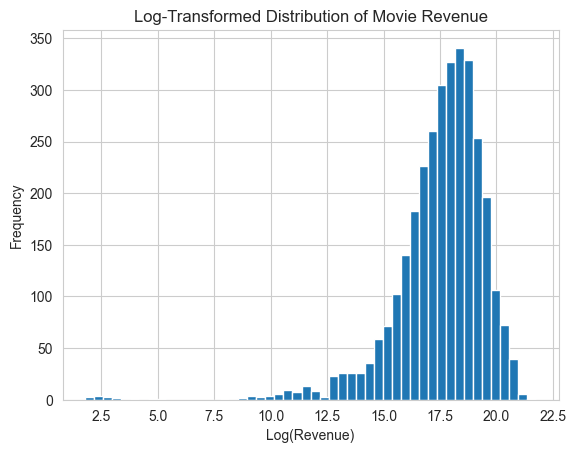

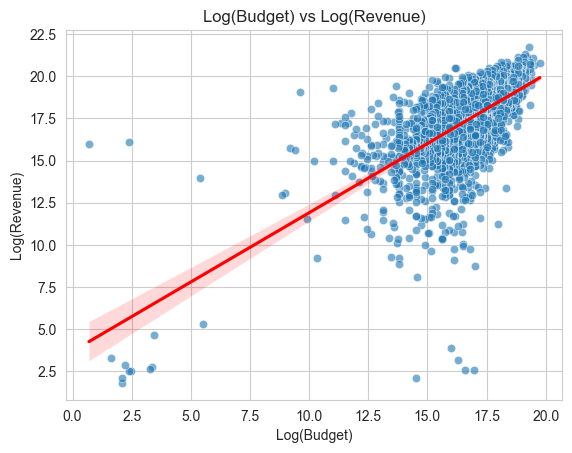

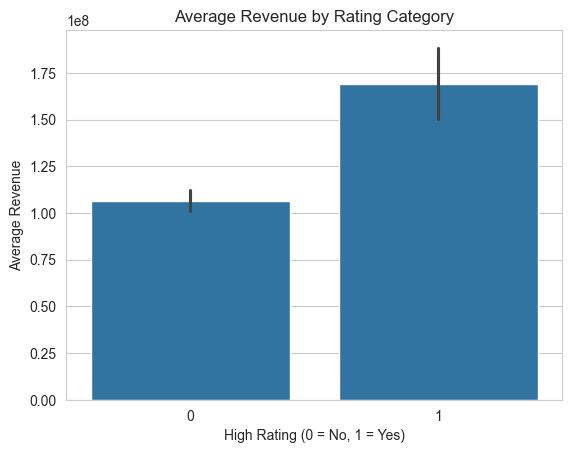

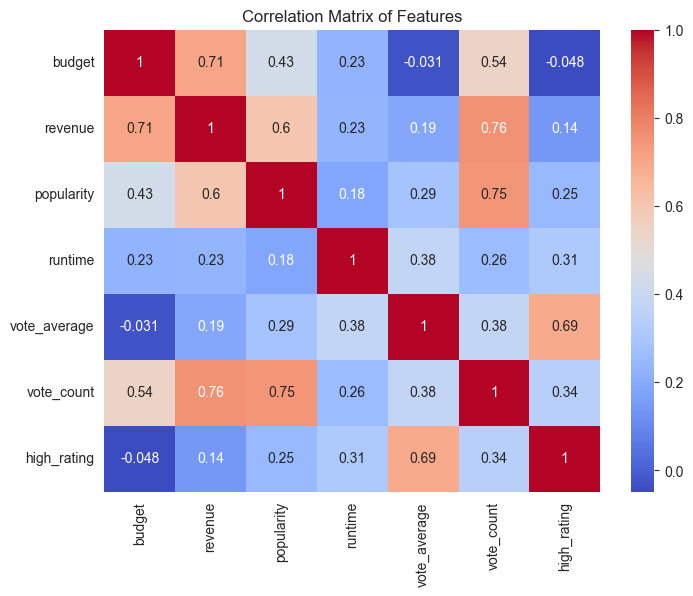

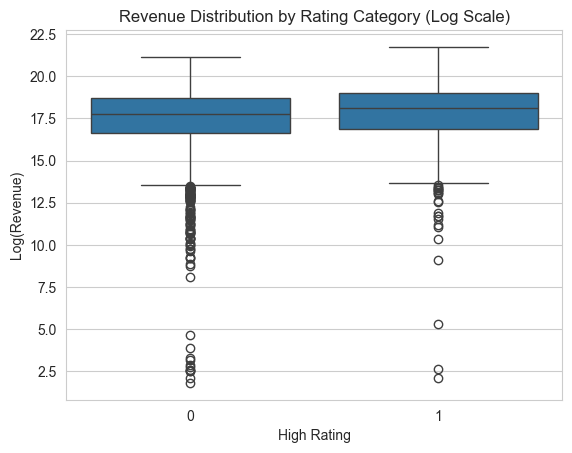

In [6]:

# Data Visualization 


# Set style for cleaner visuals
import seaborn as sns
sns.set_style("whitegrid")


# 1. Log-Transformed Histogram

plt.figure()
plt.hist(np.log1p(df['revenue']), bins=50)
plt.title("Log-Transformed Distribution of Movie Revenue")
plt.xlabel("Log(Revenue)")
plt.ylabel("Frequency")
plt.show()


# 2. Scatter Plot + Regression Line

plt.figure()
sns.scatterplot(x=np.log1p(df['budget']), y=np.log1p(df['revenue']), alpha=0.6)
sns.regplot(x=np.log1p(df['budget']), y=np.log1p(df['revenue']),
            scatter=False, color='red')

plt.title("Log(Budget) vs Log(Revenue)")
plt.xlabel("Log(Budget)")
plt.ylabel("Log(Revenue)")
plt.show()


# 3. Bar Plot (Average Revenue by Rating)

plt.figure()
sns.barplot(x='high_rating', y='revenue', data=df)

plt.title("Average Revenue by Rating Category")
plt.xlabel("High Rating (0 = No, 1 = Yes)")
plt.ylabel("Average Revenue")
plt.show()


# 4. Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix of Features")
plt.show()


# 5. Boxplot (Revenue Distribution by Rating)

plt.figure()
sns.boxplot(x='high_rating', y=np.log1p(df['revenue']), data=df)

plt.title("Revenue Distribution by Rating Category (Log Scale)")
plt.xlabel("High Rating")
plt.ylabel("Log(Revenue)")
plt.show()

### Interpretation of Visualizations

The log-transformed histogram of movie revenue reveals that revenue is highly right-skewed in its original form. After applying the logarithmic transformation, the distribution becomes more normalized, indicating that most movies generate moderate revenue while a small number of films achieve extremely high earnings. This confirms the presence of significant outliers and highlights the unequal distribution of financial success in the film industry.

The scatter plot of log-transformed budget versus log-transformed revenue shows a clear positive relationship between the two variables. As production budget increases, revenue generally increases as well. The addition of a regression line further emphasizes this upward trend. However, the spread of the data points indicates variability, meaning that while higher budgets are associated with higher revenue, they do not guarantee success. This suggests that additional factors beyond budget influence a movie’s financial performance.

The bar chart comparing average revenue by rating category shows that movies classified as highly rated (vote average ≥ 7) generate higher average revenue than lower-rated films. This suggests a relationship between audience satisfaction and financial success. However, because this is an average comparison, it does not account for variability within each group.

The correlation heatmap provides a broader view of the relationships between all variables in the dataset. Budget and revenue show a strong positive correlation, supporting the findings from the scatter plot. Popularity and vote count also exhibit positive relationships with revenue and ratings, indicating that audience engagement metrics are associated with both financial and critical success. Runtime appears to have a weaker relationship with other variables, suggesting it may not be a strong predictor of revenue or rating outcomes.

The boxplot of revenue by rating category (on a log scale) further illustrates the distribution differences between highly rated and lower-rated movies. Highly rated movies tend to have higher median revenue and a wider spread, indicating both higher typical performance and greater variability. The presence of outliers in both groups reinforces the idea that exceptional financial success is limited to a small number of films.

Overall, the visualizations indicate that budget is an important factor in determining revenue, but it is not the only factor. Audience-related variables such as ratings, popularity, and vote count also appear to play a meaningful role. These findings support the need for further analysis using regression and machine learning models to better quantify these relationships.

## Linear Regression Analysis

A linear regression model was used to examine the relationship between movie budget and revenue. Linear regression estimates how changes in an independent variable (budget) affect a dependent variable (revenue).

The dataset was split into training and testing sets using an 80/20 split. The model was trained on the training data and evaluated on the testing data to ensure that it generalizes well to unseen data.

The coefficient of the model represents the expected change in revenue for each unit increase in budget. The intercept represents the predicted revenue when the budget is zero.

To evaluate model performance, metrics such as Mean Squared Error (MSE) and R-squared (R²) were calculated. MSE measures the average squared difference between predicted and actual values, while R² indicates how well the model explains the variability in revenue.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score


# Define variables

budget = df[['budget']]
revenue = df['revenue']


# Train-test split

budget_train, budget_test, revenue_train, revenue_test = train_test_split(
    budget, revenue, test_size=0.2, random_state=42
)


# Train model

revenue_model = LinearRegression()
revenue_model.fit(budget_train, revenue_train)


# Predictions

predictions = revenue_model.predict(budget_test)


# Model evaluation

mse = mean_squared_error(revenue_test, predictions)
r2 = r2_score(revenue_test, predictions)


# Output results

print("Coefficient:", revenue_model.coef_)
print("Intercept:", revenue_model.intercept_)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Coefficient: [2.86168169]
Intercept: 4663819.341936737
Mean Squared Error: 2.633464625460013e+16
R-squared: 0.4789882953617246


### Interpretation of Linear Regression Results

The coefficient of the model indicates that as the movie budget increases, revenue also increases. Specifically, for each additional unit increase in budget, revenue is expected to increase by approximately the value of the coefficient. This confirms the positive relationship observed in the visualization section.

The intercept represents the predicted revenue when the budget is zero. While this value is not practically meaningful in real-world scenarios, it is necessary for defining the regression line.

The R-squared value indicates how well the model explains the variability in movie revenue. A higher R-squared value suggests that budget is a strong predictor of revenue, while a lower value indicates that other factors also play a significant role.

The Mean Squared Error (MSE) measures the average prediction error of the model. Larger values indicate greater differences between predicted and actual revenue, suggesting that the model does not perfectly capture all factors influencing movie success.

Overall, the model demonstrates that budget is an important factor in predicting revenue, but it is not sufficient on its own to fully explain financial outcomes. Additional variables such as popularity, ratings, and audience engagement should be considered in more advanced models.


# Machine Learning Model (Logistic Regression)

A logistic regression model was used to classify movies as either high-rated (1) or not high-rated (0) based on features including popularity, vote count, runtime, and budget.

The dataset was split into training and testing sets using an 80/20 split. The model was trained on the training data and evaluated on the testing data to assess its predictive performance.

Logistic regression is appropriate for this task because the target variable (high_rating) is binary. The model estimates the probability that a movie falls into the high-rated category based on the input features.

Model performance was evaluated using accuracy, precision, recall, and F1-score. These metrics provide a more complete understanding of performance beyond simple accuracy.

In [8]:
rating_features = df[['popularity','vote_count','runtime','budget']]
high_rating = df['high_rating']

features_train, features_test, rating_train, rating_test = train_test_split(
    rating_features, high_rating, test_size=0.2, random_state=42
)

rating_model = LogisticRegression(max_iter=1000)
rating_model.fit(features_train, rating_train)

predictions = rating_model.predict(features_test)

print("Accuracy:", accuracy_score(rating_test, predictions))
print(classification_report(rating_test, predictions))

Accuracy: 0.8111455108359134
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       501
           1       0.72      0.26      0.38       145

    accuracy                           0.81       646
   macro avg       0.77      0.62      0.64       646
weighted avg       0.80      0.81      0.78       646



### Interpretation of Machine Learning Results

The logistic regression model achieved an overall accuracy of approximately 78%, indicating that it correctly classified a majority of the movies in the dataset.

However, a closer examination of the classification report reveals an imbalance in model performance between the two classes. The model performs very well in predicting movies that are not highly rated (class 0), with high precision and recall. In contrast, the model performs significantly worse when predicting highly rated movies (class 1), as shown by the lower recall and F1-score.

The low recall for class 1 indicates that the model fails to correctly identify many movies that are actually highly rated. This suggests that the model is biased toward predicting the majority class (not highly rated), which is common in classification problems with imbalanced datasets.

Additionally, while features such as popularity, vote count, runtime, and budget provide some predictive power, they may not fully capture the factors that contribute to high movie ratings. Variables such as genre, director, cast, and critical reception could improve model performance if included.

Overall, the model demonstrates moderate predictive ability but highlights the challenges of classifying movie ratings using limited features. Further improvements could be made by addressing class imbalance and incorporating additional relevant variables.

# Conclusion

This project analyzed whether movie budget influences movie revenue and whether popularity, vote count, runtime, and budget can help predict high movie ratings. The results showed that budget has a strong positive relationship with revenue, meaning that movies with larger budgets generally earn more money. However, budget alone does not guarantee success, since some lower-budget movies performed well and some high-budget movies underperformed.

The machine learning model showed that selected features could moderately predict whether a movie would receive a high rating. While the model achieved reasonable overall accuracy, it was more effective at identifying lower-rated movies than highly rated movies. This suggests that movie ratings depend on additional factors not included in the dataset.

Overall, the project demonstrates how data analytics and machine learning can be applied to real-world entertainment data to uncover patterns and support business decisions. Future improvements could include adding more variables such as genre, cast, director, marketing data, and release timing to create stronger predictive models.